# PROSIT 4 : Pas de déjeuner gratuit

**Groupe :**
* LUU Philippe
* AFANE Youcef
* RABATEL Antonin
* RIVET Alexandre

---

## 1. Contexte
Face à la NP-Complétude du problème VRP-CDR (établie dans les prosits précédents), une approche exacte est inenvisageable pour des instances de taille réaliste. L'équipe s'oriente donc vers les **métaheuristiques** — des stratégies générales de résolution approchée capables de fournir de bonnes solutions en temps raisonnable.

Agathe, notre interlocutrice, nous alerte cependant sur plusieurs points : le Hill Climbing n'est pas une vraie métaheuristique (absence de diversification), le choix entre méthode par trajectoire et méthode par population n'est pas anodin, et surtout, le théorème *No Free Lunch* interdit de prédire quelle métaheuristique sera la meilleure sans expérimentation rigoureuse.

L'objectif est donc triple : comprendre les mécanismes fondamentaux des métaheuristiques (intensification vs diversification), en implémenter plusieurs variantes sur notre problème de tournées, et les comparer expérimentalement via un plan d'expérience structuré.

## 2. Mots inconnus / Notions à maîtriser
* **Métaheuristique** :
Cadre algorithmique général de résolution approchée, applicable à de nombreux problèmes d'optimisation combinatoire, combinant intensification et diversification.

* **Intensification (exploitation)** :
Phase où l'on concentre la recherche autour de la meilleure solution connue en explorant son voisinage en profondeur.

* **Diversification (exploration)** :
Phase où l'on force l'algorithme à visiter des régions inexplorées de l'espace de recherche pour échapper aux optima locaux.

* **Optimum local** :
Solution meilleure que tous ses voisins, mais pas nécessairement la meilleure globale.

* **Voisinage** :
Ensemble des solutions atteignables depuis une solution donnée par une transformation élémentaire (un « mouvement »).

* **Méthode par trajectoire** :
Métaheuristique maintenant une seule solution courante qu'elle fait évoluer itérativement (recuit simulé, recherche tabou).

* **Méthode par population** :
Métaheuristique manipulant un ensemble de solutions simultanément (algorithme génétique, colonies de fourmis).

* **Constructive vs Perturbative** :
Constructive : on bâtit la solution pas à pas. Perturbative : on modifie une solution existante.

* **No Free Lunch (NFL)** :
Théorème stipulant qu'aucune métaheuristique n'est universellement supérieure à toutes les autres sur l'ensemble des problèmes d'optimisation.

* **Rugosité du paysage** :
Caractérise la densité d'optima locaux dans l'espace de recherche. Un paysage rugueux nécessite plus de diversification.

* **Borne inférieure** :
Valeur minimale théorique de la fonction objectif, servant de référence pour évaluer la qualité d'une solution approchée.

* **Plan d'expérience** :
Méthodologie structurée pour tester l'influence de paramètres sur les résultats en limitant le nombre d'expériences.

## 3. Problématique
**Comment choisir, implémenter et évaluer expérimentalement une métaheuristique adaptée à la résolution approchée du VRP-CDR, en tenant compte de l'équilibre intensification/diversification et du théorème No Free Lunch ?**

## 4. Plan d'action
1. **Fondamentaux des métaheuristiques (1h30)** :
Comprendre la distinction heuristique/métaheuristique, le rôle de l'intensification et de la diversification
2. **Modélisation du voisinage pour le VRP (1h)** :
Définir les opérateurs de voisinage (2-opt, swap, insertion) et construire une solution initiale par heuristique gloutonne.
3. **Implémentation des métaheuristiques (3h)** :
Coder le Hill Climbing (référence), le recuit simulé, la recherche tabou et un algorithme génétique.
4. **Plan d'expérience et évaluation (2h)** :
Concevoir un plan d'expérience, calculer des bornes inférieures, et comparer les résultats statistiquement.
5. **Synthèse et conclusions (1h)** :
Analyser les résultats, valider ou infirmer les hypothèses, et choisir la stratégie la plus adaptée.

## 5. Réalisation

## Partie 1 : Fondamentaux des métaheuristiques

### 1.1 Heuristique vs Métaheuristique

Une **heuristique** est une méthode de résolution approchée spécifique à un problème donné. Elle fournit une solution « raisonnable » rapidement, mais sans garantie d'optimalité ni mécanisme pour échapper aux optima locaux.

Une **métaheuristique** est un cadre algorithmique général, applicable à de nombreux problèmes d'optimisation combinatoire. Elle orchestre des mécanismes d'**intensification** et de **diversification** pour parcourir efficacement l'espace de recherche.

### 1.2 Intensification vs Diversification

C'est le dilemme fondamental de toute métaheuristique :

- **Intensification (exploitation)** : on concentre la recherche autour de la meilleure solution connue. On exploite le voisinage en profondeur. Risque : rester piégé dans un optimum local.
- **Diversification (exploration)** : on force l'algorithme à visiter des régions inexplorées de l'espace de recherche. Risque : perdre du temps dans des zones peu prometteuses.

Le **Hill Climbing** ne fait **que** de l'intensification : il accepte uniquement les voisins améliorants et s'arrête dès qu'il atteint un optimum local. C'est pourquoi Agathe ne le considère pas comme une vraie métaheuristique.

## Partie 2 : Modélisation du voisinage et outils de base

### 2.1 Représentation d'une solution

Une solution du VRP est une liste ordonnée de clients à visiter. Le véhicule part du dépôt (indice 0), visite les clients dans l'ordre, et revient au dépôt.

Exemple : `[0, 3, 1, 4, 2, 0]` — le véhicule part du dépôt, visite les clients 3, 1, 4, 2 puis revient au dépôt.

### 2.2 Opérateurs de voisinage

Pour appliquer des métaheuristiques à base de voisinage, il faut définir les **mouvements** (transformations élémentaires) qui permettent de passer d'une solution à une solution voisine :

1. **2-opt** : on inverse un sous-segment de la tournée (on retire deux arêtes et on les reconnecte de manière croisée)
2. **Swap** : on échange la position de deux clients
3. **Insertion** : on retire un client et on le réinsère à une autre position

### 2.3 Solution initiale

On utilise l'heuristique gloutonne du **plus proche voisin** : à chaque étape, on choisit le client non visité le plus proche du client courant.

Instance générée : 20 clients + 1 dépôt
Dépôt en : (50.0, 50.0)

Solution initiale (plus proche voisin) : coût = 510.67

Démonstration des opérateurs de voisinage :
  Tournée originale : [0, 20, 2, 5, 13, 1, 17, 6, 4, 14, 9, 12, 10, 16, 11, 15, 7, 19, 8, 3, 18, 0]
  Après 2-opt       : [0, 20, 2, 5, 1, 13, 17, 6, 4, 14, 9, 12, 10, 16, 11, 15, 7, 19, 8, 3, 18, 0]
  Après swap        : [0, 20, 2, 5, 13, 1, 17, 6, 14, 4, 9, 12, 10, 16, 11, 15, 7, 19, 8, 3, 18, 0]
  Après insertion   : [0, 20, 2, 5, 13, 4, 1, 17, 6, 14, 9, 12, 10, 16, 11, 15, 7, 19, 8, 3, 18, 0]


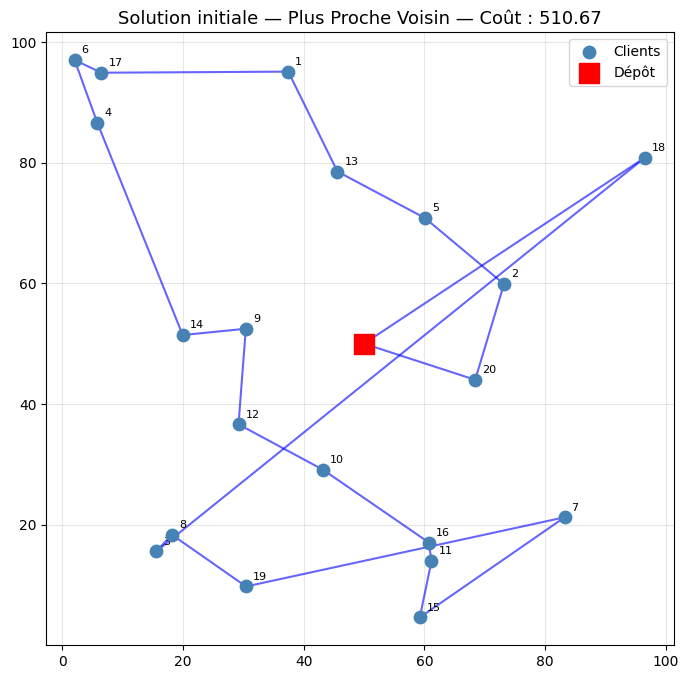

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
import time

random.seed(42)
np.random.seed(42)


# ============================================================
# Génération d'instance
# ============================================================

def generer_instance(n_clients, largeur=100, hauteur=100, seed=None):
    """
    Génère une instance de VRP.

    Paramètres :
        n_clients : nombre de clients (hors dépôt)
        largeur, hauteur : dimensions de la zone géographique
        seed : graine aléatoire pour la reproductibilité

    Retourne :
        coords : tableau (n_clients+1, 2) avec le dépôt en indice 0
        dist_matrix : matrice de distances euclidiennes
    """
    if seed is not None:
        np.random.seed(seed)
    depot = np.array([[largeur / 2, hauteur / 2]])
    clients = np.random.rand(n_clients, 2) * [largeur, hauteur]
    coords = np.vstack([depot, clients])
    n = len(coords)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = np.linalg.norm(coords[i] - coords[j])
            dist_matrix[i][j] = d
            dist_matrix[j][i] = d
    return coords, dist_matrix


# ============================================================
# Fonctions utilitaires
# ============================================================

def cout_tournee(tournee, dist_matrix):
    """Calcule le coût total d'une tournée."""
    return sum(dist_matrix[tournee[i]][tournee[i+1]] for i in range(len(tournee) - 1))


def afficher_tournee(coords, tournee, titre="Tournée VRP", cout=None):
    """Affiche graphiquement une tournée VRP."""
    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    for i in range(len(tournee) - 1):
        a, b = tournee[i], tournee[i + 1]
        ax.plot([coords[a][0], coords[b][0]],
                [coords[a][1], coords[b][1]], 'b-', alpha=0.6, linewidth=1.5)
    clients = coords[1:]
    ax.scatter(clients[:, 0], clients[:, 1], c='steelblue', s=80, zorder=5, label='Clients')
    for i in range(1, len(coords)):
        ax.annotate(str(i), coords[i], textcoords="offset points",
                    xytext=(5, 5), fontsize=8)
    ax.scatter(coords[0][0], coords[0][1], c='red', s=200, marker='s', zorder=6, label='Dépôt')
    titre_complet = titre
    if cout is not None:
        titre_complet += f" — Coût : {cout:.2f}"
    ax.set_title(titre_complet, fontsize=13)
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# Opérateurs de voisinage
# ============================================================

def voisin_2opt(tournee):
    """Mouvement 2-opt : inverse un sous-segment de la tournée."""
    n = len(tournee)
    nouvelle = tournee[:]
    i = random.randint(1, n - 3)
    j = random.randint(i + 1, n - 2)
    nouvelle[i:j+1] = reversed(nouvelle[i:j+1])
    return nouvelle


def voisin_swap(tournee):
    """Mouvement Swap : échange deux clients de position."""
    n = len(tournee)
    nouvelle = tournee[:]
    i = random.randint(1, n - 2)
    j = random.randint(1, n - 2)
    while j == i:
        j = random.randint(1, n - 2)
    nouvelle[i], nouvelle[j] = nouvelle[j], nouvelle[i]
    return nouvelle


def voisin_insertion(tournee):
    """Mouvement Insertion : retire un client et le réinsère ailleurs."""
    n = len(tournee)
    nouvelle = tournee[:]
    i = random.randint(1, n - 2)
    client = nouvelle.pop(i)
    j = random.randint(1, len(nouvelle) - 1)
    nouvelle.insert(j, client)
    return nouvelle


# ============================================================
# Heuristique du plus proche voisin (solution initiale)
# ============================================================

def plus_proche_voisin(dist_matrix):
    """
    Heuristique gloutonne du plus proche voisin.
    Construit une tournée en choisissant toujours le client
    non visité le plus proche.
    """
    n = len(dist_matrix)
    visite = [False] * n
    tournee = [0]
    visite[0] = True
    for _ in range(n - 1):
        courant = tournee[-1]
        meilleur = None
        meilleure_dist = float('inf')
        for j in range(n):
            if not visite[j] and dist_matrix[courant][j] < meilleure_dist:
                meilleur = j
                meilleure_dist = dist_matrix[courant][j]
        tournee.append(meilleur)
        visite[meilleur] = True
    tournee.append(0)
    return tournee


# ============================================================
# Test sur une instance à 20 clients
# ============================================================

coords, dist_matrix = generer_instance(20, seed=42)
n_clients = len(coords) - 1

print(f"Instance générée : {n_clients} clients + 1 dépôt")
print(f"Dépôt en : ({coords[0][0]:.1f}, {coords[0][1]:.1f})")

# Solution initiale
tournee_ppv = plus_proche_voisin(dist_matrix)
cout_ppv = cout_tournee(tournee_ppv, dist_matrix)
print(f"\nSolution initiale (plus proche voisin) : coût = {cout_ppv:.2f}")

# Démonstration des opérateurs de voisinage
print(f"\nDémonstration des opérateurs de voisinage :")
print(f"  Tournée originale : {tournee_ppv}")
print(f"  Après 2-opt       : {voisin_2opt(tournee_ppv)}")
print(f"  Après swap        : {voisin_swap(tournee_ppv)}")
print(f"  Après insertion   : {voisin_insertion(tournee_ppv)}")

afficher_tournee(coords, tournee_ppv, "Solution initiale — Plus Proche Voisin", cout_ppv)

## Partie 3 : Implémentation des métaheuristiques

On implémente et compare quatre approches, de la plus simple à la plus élaborée :

1. **Hill Climbing** — référence (pas une vraie métaheuristique, uniquement intensification)
2. **Recuit Simulé** — trajectoire, diversification stochastique via la température
3. **Recherche Tabou** — trajectoire, diversification par mémoire
4. **Algorithme Génétique** — population, diversification par croisement et mutation

---

### 3.1 Hill Climbing

**Principe** : à chaque itération, on génère un voisin. Si le voisin est meilleur, on le garde. Sinon, on ne bouge pas. On s'arrête quand aucune amélioration n'est trouvée après un certain nombre d'essais.

**Limite** : uniquement de l'intensification → piégé au premier optimum local rencontré.

Hill Climbing : coût = 414.65 (temps = 0.011s)
Amélioration vs solution initiale : 18.8%


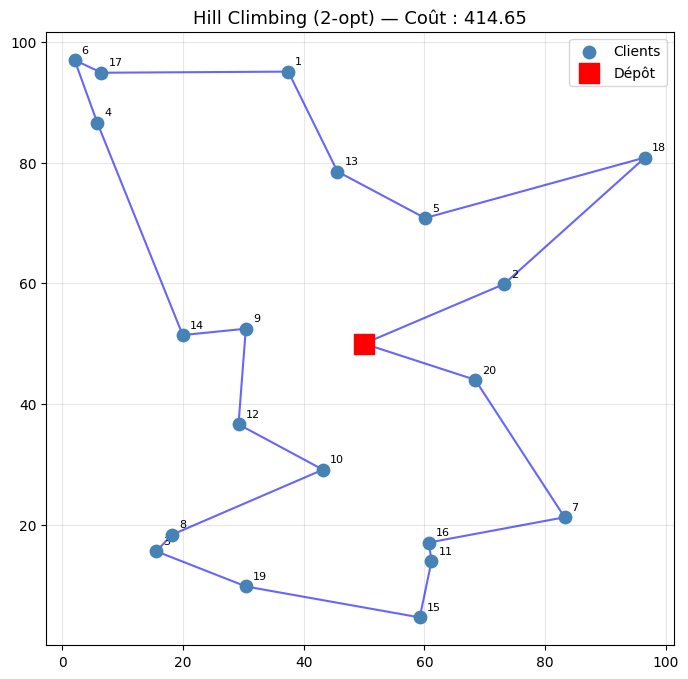

In [2]:
def hill_climbing(dist_matrix, tournee_init, max_iter=5000, operateur=voisin_2opt):
    """
    Hill Climbing : accepte uniquement les améliorations.

    Paramètres :
        dist_matrix  : matrice de distances
        tournee_init : solution de départ
        max_iter     : nombre maximal d'itérations
        operateur    : fonction de voisinage à utiliser

    Retourne : (meilleure_tournee, meilleur_cout, historique_couts)
    """
    tournee = tournee_init[:]
    cout = cout_tournee(tournee, dist_matrix)
    historique = [cout]
    sans_amelioration = 0

    for i in range(max_iter):
        voisin = operateur(tournee)
        cout_v = cout_tournee(voisin, dist_matrix)

        if cout_v < cout:
            tournee = voisin
            cout = cout_v
            sans_amelioration = 0
        else:
            sans_amelioration += 1

        historique.append(cout)

        if sans_amelioration > 500:
            break

    return tournee, cout, historique


# Exécution
t0 = time.time()
tournee_hc, cout_hc, hist_hc = hill_climbing(dist_matrix, tournee_ppv)
temps_hc = time.time() - t0

print(f"Hill Climbing : coût = {cout_hc:.2f} (temps = {temps_hc:.3f}s)")
print(f"Amélioration vs solution initiale : {(cout_ppv - cout_hc) / cout_ppv * 100:.1f}%")
afficher_tournee(coords, tournee_hc, "Hill Climbing (2-opt)", cout_hc)

### 3.2 Recuit Simulé (Simulated Annealing)

**Principe** : inspiré du recuit en métallurgie. On accepte les solutions améliorantes, mais aussi les solutions dégradantes avec une probabilité dépendant de la **température** $T$ :

$$P(\text{accepter}) = e^{-\frac{\Delta f}{T}}$$

où $\Delta f = f(\text{voisin}) - f(\text{courant}) > 0$ est la dégradation.

- **Température élevée** → forte diversification (on accepte beaucoup de dégradations)
- **Température basse** → forte intensification (comportement proche du Hill Climbing)

La température diminue progressivement selon un **schéma de refroidissement** géométrique : $T_{k+1} = \alpha \cdot T_k$.

Recuit Simulé : coût = 414.65 (temps = 0.029s)
Amélioration vs solution initiale : 18.8%


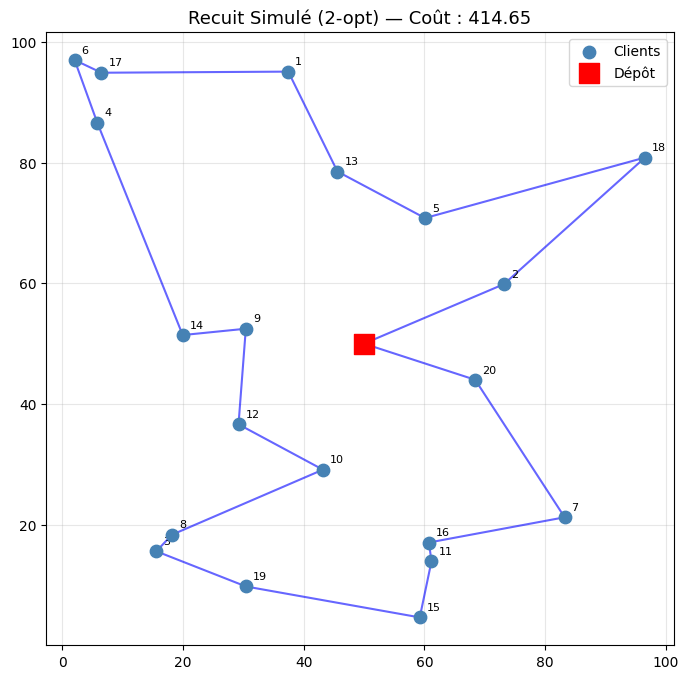

In [3]:
def recuit_simule(dist_matrix, tournee_init, T_init=100, T_min=0.01,
                  alpha=0.995, max_iter=10000, operateur=voisin_2opt):
    """
    Recuit Simulé.

    Paramètres :
        T_init   : température initiale
        T_min    : température finale (critère d'arrêt)
        alpha    : facteur de refroidissement (0 < alpha < 1)
        max_iter : nombre max d'itérations

    Retourne : (meilleure_tournee, meilleur_cout, historique_couts)
    """
    tournee = tournee_init[:]
    cout = cout_tournee(tournee, dist_matrix)
    meilleure_tournee = tournee[:]
    meilleur_cout = cout
    T = T_init
    historique = [cout]

    iteration = 0
    while T > T_min and iteration < max_iter:
        voisin = operateur(tournee)
        cout_v = cout_tournee(voisin, dist_matrix)
        delta = cout_v - cout

        # Critère de Metropolis
        if delta < 0:
            tournee = voisin
            cout = cout_v
        elif random.random() < np.exp(-delta / T):
            tournee = voisin
            cout = cout_v

        if cout < meilleur_cout:
            meilleure_tournee = tournee[:]
            meilleur_cout = cout

        T *= alpha
        iteration += 1
        historique.append(meilleur_cout)

    return meilleure_tournee, meilleur_cout, historique


# Exécution
t0 = time.time()
tournee_sa, cout_sa, hist_sa = recuit_simule(dist_matrix, tournee_ppv)
temps_sa = time.time() - t0

print(f"Recuit Simulé : coût = {cout_sa:.2f} (temps = {temps_sa:.3f}s)")
print(f"Amélioration vs solution initiale : {(cout_ppv - cout_sa) / cout_ppv * 100:.1f}%")
afficher_tournee(coords, tournee_sa, "Recuit Simulé (2-opt)", cout_sa)

### 3.3 Recherche Tabou

**Principe** : à chaque itération, on explore le voisinage et on choisit le **meilleur voisin**, même s'il est moins bon que la solution courante (diversification forcée). Pour éviter de revenir en arrière (cycler), on maintient une **liste tabou** qui interdit les mouvements récemment effectués.

- **Intensification** : on choisit le meilleur voisin disponible
- **Diversification** : on accepte les dégradations, la liste tabou empêche le cyclage
- **Critère d'aspiration** : un mouvement tabou est quand même accepté s'il améliore la meilleure solution connue

Recherche Tabou : coût = 406.56 (temps = 1.427s)
Amélioration vs solution initiale : 20.4%


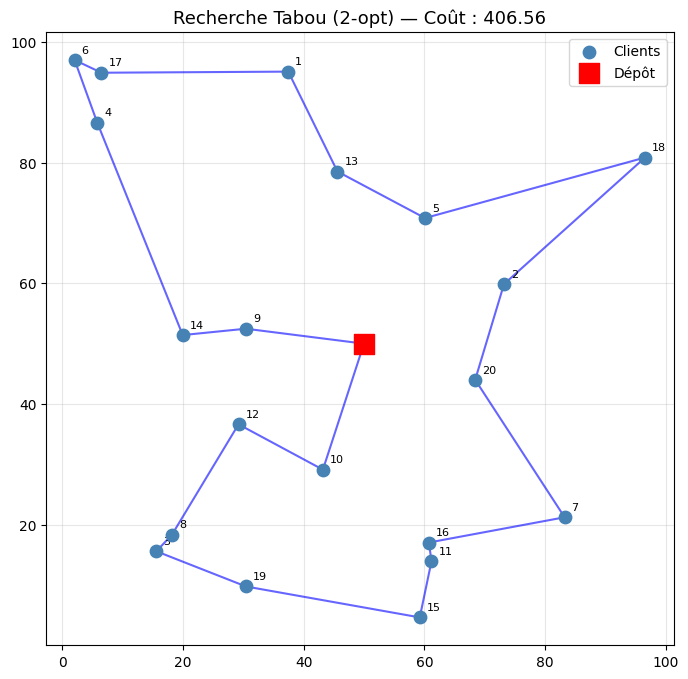

In [4]:
def recherche_tabou(dist_matrix, tournee_init, max_iter=2000,
                    taille_tabou=20, n_voisins=50):
    """
    Recherche Tabou avec mouvement 2-opt.

    Paramètres :
        taille_tabou : durée pendant laquelle un mouvement est interdit
        n_voisins    : nombre de voisins explorés à chaque itération

    Retourne : (meilleure_tournee, meilleur_cout, historique_couts)
    """
    tournee = tournee_init[:]
    cout = cout_tournee(tournee, dist_matrix)
    meilleure_tournee = tournee[:]
    meilleur_cout = cout
    liste_tabou = []
    historique = [cout]

    for iteration in range(max_iter):
        meilleur_voisin = None
        meilleur_cout_voisin = float('inf')
        meilleur_mouvement = None
        n = len(tournee)

        for _ in range(n_voisins):
            i = random.randint(1, n - 3)
            j = random.randint(i + 1, n - 2)
            voisin = tournee[:]
            voisin[i:j+1] = reversed(voisin[i:j+1])
            cout_v = cout_tournee(voisin, dist_matrix)
            mouvement = (i, j)

            est_tabou = mouvement in liste_tabou

            # Critère d'aspiration
            if est_tabou and cout_v >= meilleur_cout:
                continue

            if cout_v < meilleur_cout_voisin:
                meilleur_voisin = voisin
                meilleur_cout_voisin = cout_v
                meilleur_mouvement = mouvement

        if meilleur_voisin is None:
            break

        tournee = meilleur_voisin
        cout = meilleur_cout_voisin

        liste_tabou.append(meilleur_mouvement)
        if len(liste_tabou) > taille_tabou:
            liste_tabou.pop(0)

        if cout < meilleur_cout:
            meilleure_tournee = tournee[:]
            meilleur_cout = cout

        historique.append(meilleur_cout)

    return meilleure_tournee, meilleur_cout, historique


# Exécution
t0 = time.time()
tournee_tabou, cout_tabou, hist_tabou = recherche_tabou(dist_matrix, tournee_ppv)
temps_tabou = time.time() - t0

print(f"Recherche Tabou : coût = {cout_tabou:.2f} (temps = {temps_tabou:.3f}s)")
print(f"Amélioration vs solution initiale : {(cout_ppv - cout_tabou) / cout_ppv * 100:.1f}%")
afficher_tournee(coords, tournee_tabou, "Recherche Tabou (2-opt)", cout_tabou)

### 3.4 Algorithme Génétique

**Principe** : inspiré de l'évolution naturelle. On manipule une **population** de solutions qui évolue par :

- **Sélection** : les meilleures solutions ont plus de chances d'être choisies comme parents
- **Croisement (crossover)** : deux parents produisent un enfant combinant leurs caractéristiques
- **Mutation** : perturbation aléatoire pour maintenir la diversité

**Intensification** : via la sélection (les meilleurs survivent).  
**Diversification** : via la mutation et le croisement.

Pour le TSP/VRP, on utilise le croisement **OX (Order Crossover)** qui préserve l'ordre relatif des clients.

Algo. Génétique : coût = 417.16 (temps = 0.478s)
Amélioration vs solution initiale : 18.3%


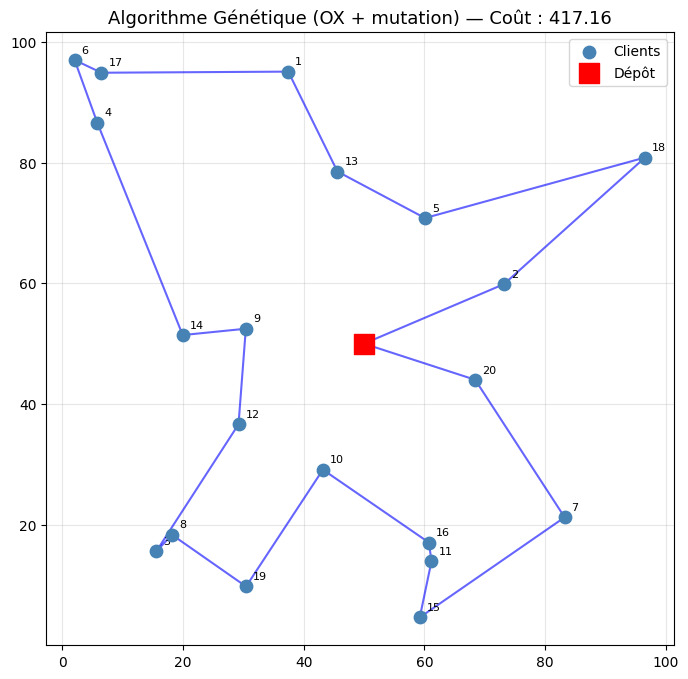

In [5]:
def croisement_ox(parent1, parent2):
    """
    Order Crossover (OX) pour le TSP/VRP.
    Travaille sur la partie clients (sans le dépôt de début et fin).
    """
    p1 = parent1[1:-1]
    p2 = parent2[1:-1]
    n = len(p1)
    i = random.randint(0, n - 2)
    j = random.randint(i + 1, n - 1)
    enfant = [None] * n
    enfant[i:j+1] = p1[i:j+1]
    elements_p1 = set(p1[i:j+1])
    pos = (j + 1) % n
    for elem in p2:
        if elem not in elements_p1:
            while enfant[pos] is not None:
                pos = (pos + 1) % n
            enfant[pos] = elem
            pos = (pos + 1) % n
    return [0] + enfant + [0]


def mutation(tournee, taux_mutation=0.1):
    """Mutation par swap avec une probabilité donnée."""
    if random.random() < taux_mutation:
        return voisin_swap(tournee)
    return tournee[:]


def selection_tournoi(population, couts, taille_tournoi=3):
    """Sélection par tournoi : choisit le meilleur parmi k individus aléatoires."""
    candidats = random.sample(range(len(population)), taille_tournoi)
    meilleur = min(candidats, key=lambda i: couts[i])
    return population[meilleur]


def algorithme_genetique(dist_matrix, n_clients, taille_pop=50,
                         n_generations=500, taux_mutation=0.15,
                         taille_tournoi=3):
    """
    Algorithme Génétique pour le VRP/TSP.

    Paramètres :
        taille_pop     : taille de la population
        n_generations  : nombre de générations
        taux_mutation  : probabilité de mutation par individu
        taille_tournoi : nombre de candidats dans la sélection par tournoi

    Retourne : (meilleure_tournee, meilleur_cout, historique_couts)
    """
    # Initialisation : population aléatoire + solution PPV
    population = []
    for _ in range(taille_pop):
        perm = list(range(1, n_clients + 1))
        random.shuffle(perm)
        population.append([0] + perm + [0])
    population[0] = plus_proche_voisin(dist_matrix)

    couts = [cout_tournee(ind, dist_matrix) for ind in population]
    meilleur_idx = np.argmin(couts)
    meilleure_tournee = population[meilleur_idx][:]
    meilleur_cout = couts[meilleur_idx]
    historique = [meilleur_cout]

    for gen in range(n_generations):
        nouvelle_pop = [meilleure_tournee[:]]  # Élitisme

        while len(nouvelle_pop) < taille_pop:
            parent1 = selection_tournoi(population, couts, taille_tournoi)
            parent2 = selection_tournoi(population, couts, taille_tournoi)
            enfant = croisement_ox(parent1, parent2)
            enfant = mutation(enfant, taux_mutation)
            nouvelle_pop.append(enfant)

        population = nouvelle_pop
        couts = [cout_tournee(ind, dist_matrix) for ind in population]
        idx = np.argmin(couts)
        if couts[idx] < meilleur_cout:
            meilleure_tournee = population[idx][:]
            meilleur_cout = couts[idx]
        historique.append(meilleur_cout)

    return meilleure_tournee, meilleur_cout, historique


# Exécution
t0 = time.time()
tournee_ga, cout_ga, hist_ga = algorithme_genetique(dist_matrix, n_clients)
temps_ga = time.time() - t0

print(f"Algo. Génétique : coût = {cout_ga:.2f} (temps = {temps_ga:.3f}s)")
print(f"Amélioration vs solution initiale : {(cout_ppv - cout_ga) / cout_ppv * 100:.1f}%")
afficher_tournee(coords, tournee_ga, "Algorithme Génétique (OX + mutation)", cout_ga)

### 3.5 Comparaison des courbes de convergence

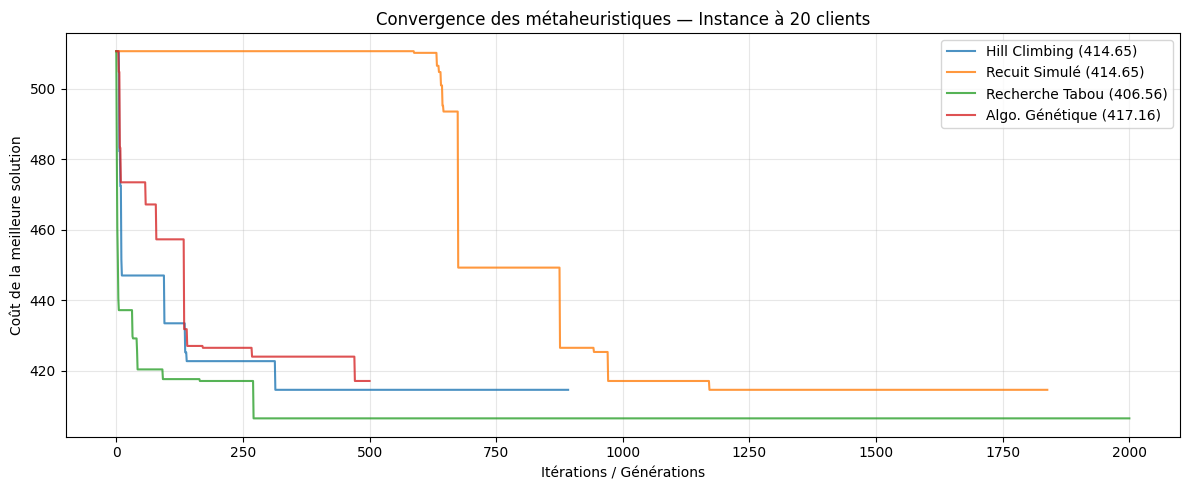


=== Récapitulatif sur l'instance de référence ===
Méthode                    Coût   Amélioration      Temps
----------------------------------------------------------
Plus Proche Voisin       510.67    (référence)          —
Hill Climbing            414.65          18.8%     0.011s
Recuit Simulé            414.65          18.8%     0.029s
Recherche Tabou          406.56          20.4%     1.427s
Algo. Génétique          417.16          18.3%     0.478s


In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist_hc, label=f'Hill Climbing ({cout_hc:.2f})', alpha=0.8)
ax.plot(hist_sa, label=f'Recuit Simulé ({cout_sa:.2f})', alpha=0.8)
ax.plot(hist_tabou, label=f'Recherche Tabou ({cout_tabou:.2f})', alpha=0.8)
ax.plot(hist_ga, label=f'Algo. Génétique ({cout_ga:.2f})', alpha=0.8)
ax.set_xlabel('Itérations / Générations')
ax.set_ylabel('Coût de la meilleure solution')
ax.set_title('Convergence des métaheuristiques — Instance à 20 clients')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n=== Récapitulatif sur l'instance de référence ===")
print(f"{'Méthode':<22} {'Coût':>8} {'Amélioration':>14} {'Temps':>10}")
print("-" * 58)
print(f"{'Plus Proche Voisin':<22} {cout_ppv:>8.2f} {'(référence)':>14} {'—':>10}")
print(f"{'Hill Climbing':<22} {cout_hc:>8.2f} {(cout_ppv-cout_hc)/cout_ppv*100:>13.1f}% {temps_hc:>9.3f}s")
print(f"{'Recuit Simulé':<22} {cout_sa:>8.2f} {(cout_ppv-cout_sa)/cout_ppv*100:>13.1f}% {temps_sa:>9.3f}s")
print(f"{'Recherche Tabou':<22} {cout_tabou:>8.2f} {(cout_ppv-cout_tabou)/cout_ppv*100:>13.1f}% {temps_tabou:>9.3f}s")
print(f"{'Algo. Génétique':<22} {cout_ga:>8.2f} {(cout_ppv-cout_ga)/cout_ppv*100:>13.1f}% {temps_ga:>9.3f}s")

## Partie 4 : Plan d'expérience et évaluation

Comme le souligne Agathe, il est essentiel d'avoir un **plan d'expérience** structuré pour obtenir des résultats représentatifs.

### 4.1 Borne inférieure

Pour évaluer la qualité de nos solutions sans connaître l'optimum exact, on utilise une **borne inférieure** basée sur l'arbre couvrant minimum. Pour le TSP, le coût est une borne inférieure car toute tournée hamiltonienne contient un arbre couvrant.

### 4.2 Facteurs du plan d'expérience

| Facteur | Valeurs testées |
|---------|----------------|
| Taille de l'instance ($n$) | 10, 20, 50 |
| Métaheuristique | HC, SA, Tabou, GA |
| Graine aléatoire | 5 graines par configuration |

**Métriques** : coût final, temps d'exécution, écart relatif à la borne inférieure.

In [7]:
def borne_inferieure_mst(dist_matrix):
    """
    Borne inférieure basée sur l'arbre couvrant minimum (MST).
    Utilise l'algorithme de Prim.

    Complexité : O(n²)
    """
    n = len(dist_matrix)
    dans_arbre = [False] * n
    cout_min = [float('inf')] * n
    cout_min[0] = 0
    cout_total = 0

    for _ in range(n):
        u = -1
        for v in range(n):
            if not dans_arbre[v] and (u == -1 or cout_min[v] < cout_min[u]):
                u = v
        dans_arbre[u] = True
        cout_total += cout_min[u]
        for v in range(n):
            if not dans_arbre[v] and dist_matrix[u][v] < cout_min[v]:
                cout_min[v] = dist_matrix[u][v]

    return cout_total


# Vérification sur l'instance de référence
bi = borne_inferieure_mst(dist_matrix)
print(f"Borne inférieure (MST) : {bi:.2f}")
print(f"\nÉcarts à la borne inférieure :")
print(f"  Hill Climbing    : {(cout_hc - bi) / bi * 100:.1f}%")
print(f"  Recuit Simulé    : {(cout_sa - bi) / bi * 100:.1f}%")
print(f"  Recherche Tabou  : {(cout_tabou - bi) / bi * 100:.1f}%")
print(f"  Algo. Génétique  : {(cout_ga - bi) / bi * 100:.1f}%")

Borne inférieure (MST) : 322.35

Écarts à la borne inférieure :
  Hill Climbing    : 28.6%
  Recuit Simulé    : 28.6%
  Recherche Tabou  : 26.1%
  Algo. Génétique  : 29.4%


In [8]:
# ============================================================
# Exécution du plan d'expérience complet
# ============================================================

tailles = [10, 20, 50]
graines = [42, 123, 456, 789, 1024]
resultats = []

for n_cl in tailles:
    for seed in graines:
        c, dm = generer_instance(n_cl, seed=seed)
        t_init = plus_proche_voisin(dm)
        bi = borne_inferieure_mst(dm)

        # Hill Climbing
        random.seed(seed)
        t0 = time.time()
        _, cout, _ = hill_climbing(dm, t_init, max_iter=5000)
        temps = time.time() - t0
        resultats.append({
            'n': n_cl, 'seed': seed, 'methode': 'Hill Climbing',
            'cout': cout, 'temps': temps, 'ecart_bi': (cout - bi) / bi * 100
        })

        # Recuit Simulé
        random.seed(seed)
        t0 = time.time()
        _, cout, _ = recuit_simule(dm, t_init, max_iter=10000)
        temps = time.time() - t0
        resultats.append({
            'n': n_cl, 'seed': seed, 'methode': 'Recuit Simulé',
            'cout': cout, 'temps': temps, 'ecart_bi': (cout - bi) / bi * 100
        })

        # Recherche Tabou
        random.seed(seed)
        t0 = time.time()
        _, cout, _ = recherche_tabou(dm, t_init, max_iter=2000)
        temps = time.time() - t0
        resultats.append({
            'n': n_cl, 'seed': seed, 'methode': 'Recherche Tabou',
            'cout': cout, 'temps': temps, 'ecart_bi': (cout - bi) / bi * 100
        })

        # Algorithme Génétique
        random.seed(seed)
        np.random.seed(seed)
        t0 = time.time()
        _, cout, _ = algorithme_genetique(dm, n_cl, taille_pop=50, n_generations=300)
        temps = time.time() - t0
        resultats.append({
            'n': n_cl, 'seed': seed, 'methode': 'Algo. Génétique',
            'cout': cout, 'temps': temps, 'ecart_bi': (cout - bi) / bi * 100
        })

print(f"Plan d'expérience terminé : {len(resultats)} expériences réalisées.")

Plan d'expérience terminé : 60 expériences réalisées.


In [9]:
# ============================================================
# Tableau de synthèse des résultats
# ============================================================

methodes = ['Hill Climbing', 'Recuit Simulé', 'Recherche Tabou', 'Algo. Génétique']

print("=" * 85)
print(f"{'Méthode':<20} {'n':>5} {'Coût moyen':>12} {'Écart BI (%)':>14} {'Temps moyen (s)':>16}")
print("=" * 85)

for n_cl in tailles:
    for meth in methodes:
        subset = [r for r in resultats if r['n'] == n_cl and r['methode'] == meth]
        cout_moy = np.mean([r['cout'] for r in subset])
        ecart_moy = np.mean([r['ecart_bi'] for r in subset])
        temps_moy = np.mean([r['temps'] for r in subset])
        print(f"{meth:<20} {n_cl:>5} {cout_moy:>12.2f} {ecart_moy:>13.1f}% {temps_moy:>15.3f}")
    print("-" * 85)

Méthode                  n   Coût moyen   Écart BI (%)  Temps moyen (s)
Hill Climbing           10       291.05          45.0%           0.005
Recuit Simulé           10       288.97          43.9%           0.016
Recherche Tabou         10       288.61          43.7%           0.729
Algo. Génétique         10       288.61          43.7%           0.259
-------------------------------------------------------------------------------------
Hill Climbing           20       380.61          29.2%           0.010
Recuit Simulé           20       383.86          30.3%           0.023
Recherche Tabou         20       375.75          27.5%           1.179
Algo. Génétique         20       386.17          31.2%           0.302
-------------------------------------------------------------------------------------
Hill Climbing           50       622.26          29.8%           0.035
Recuit Simulé           50       683.77          42.7%           0.039
Recherche Tabou         50       599.32       

/var/folders/_k/j12t2t3x19s6q7nn2nx1zz_m0000gn/T/ipykernel_32701/2697170386.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_par_methode, labels=labels, patch_artist=True)
/var/folders/_k/j12t2t3x19s6q7nn2nx1zz_m0000gn/T/ipykernel_32701/2697170386.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_par_methode, labels=labels, patch_artist=True)
/var/folders/_k/j12t2t3x19s6q7nn2nx1zz_m0000gn/T/ipykernel_32701/2697170386.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_par_methode, labels=labels, patch_artist=True)


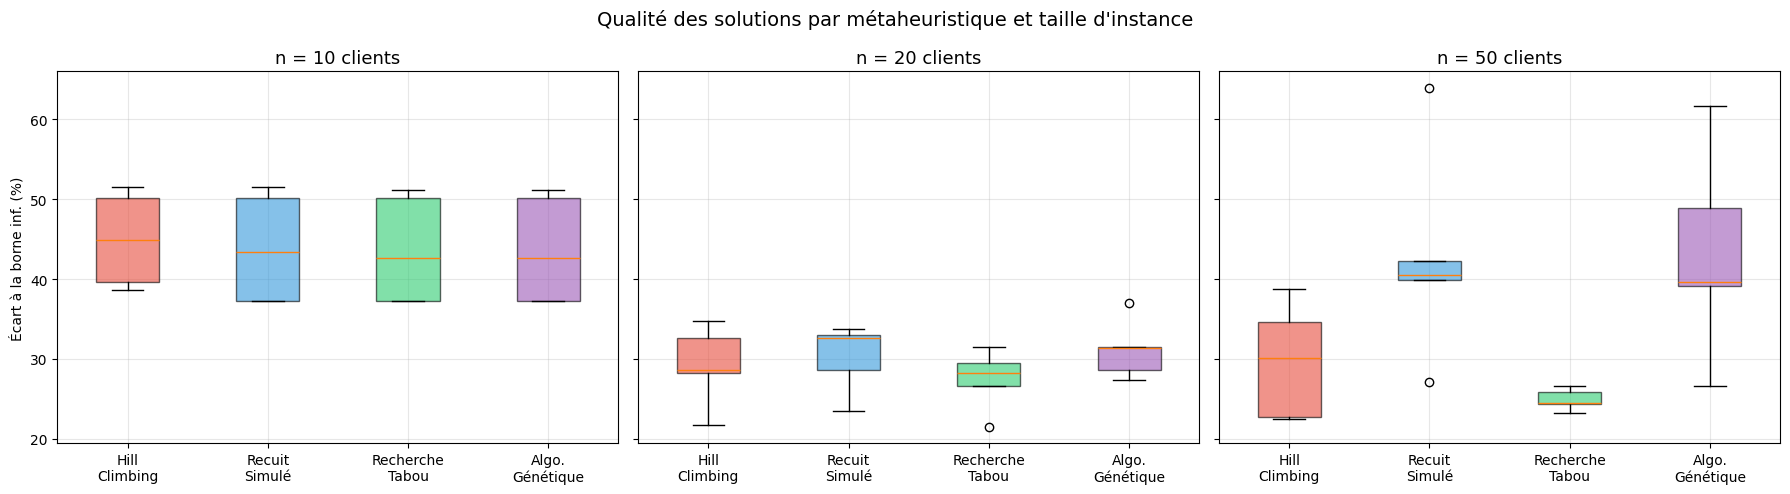

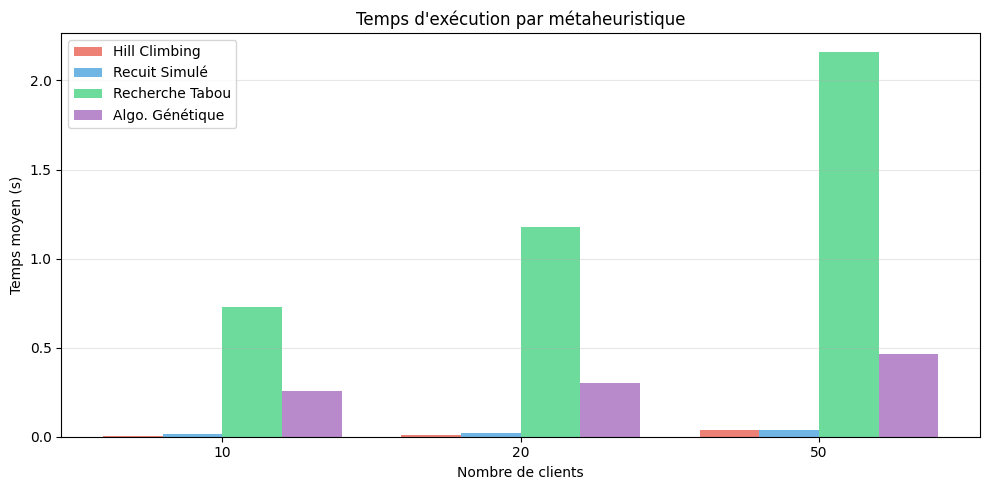

In [10]:
# ============================================================
# Visualisations du plan d'expérience
# ============================================================

couleurs = {'Hill Climbing': '#e74c3c', 'Recuit Simulé': '#3498db',
            'Recherche Tabou': '#2ecc71', 'Algo. Génétique': '#9b59b6'}

# --- Boxplots : écart à la borne inférieure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for idx, n_cl in enumerate(tailles):
    ax = axes[idx]
    data_par_methode = []
    labels = []
    colors = []
    for meth in methodes:
        subset = [r['ecart_bi'] for r in resultats if r['n'] == n_cl and r['methode'] == meth]
        data_par_methode.append(subset)
        labels.append(meth.replace(' ', '\n'))
        colors.append(couleurs[meth])
    bp = ax.boxplot(data_par_methode, labels=labels, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f'n = {n_cl} clients', fontsize=13)
    ax.set_ylabel('Écart à la borne inf. (%)' if idx == 0 else '')
    ax.grid(True, alpha=0.3)
fig.suptitle('Qualité des solutions par métaheuristique et taille d\'instance', fontsize=14)
plt.tight_layout()
plt.show()

# --- Barres : temps d'exécution ---
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(tailles))
largeur = 0.2
for i, meth in enumerate(methodes):
    temps_moyens = []
    for n_cl in tailles:
        subset = [r['temps'] for r in resultats if r['n'] == n_cl and r['methode'] == meth]
        temps_moyens.append(np.mean(subset))
    ax.bar(x + i * largeur, temps_moyens, largeur, label=meth,
           color=couleurs[meth], alpha=0.7)
ax.set_xlabel('Nombre de clients')
ax.set_ylabel('Temps moyen (s)')
ax.set_title('Temps d\'exécution par métaheuristique')
ax.set_xticks(x + 1.5 * largeur)
ax.set_xticklabels(tailles)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# Test statistique
# ============================================================

from scipy import stats

print("Test de Kruskal-Wallis (non paramétrique) sur l'écart à la borne inférieure")
print("H0 : toutes les métaheuristiques ont les mêmes performances")
print("=" * 65)

for n_cl in tailles:
    groupes = []
    for meth in methodes:
        subset = [r['ecart_bi'] for r in resultats if r['n'] == n_cl and r['methode'] == meth]
        groupes.append(subset)

    stat, p_value = stats.kruskal(*groupes)
    print(f"\nn = {n_cl} clients : H = {stat:.4f}, p-value = {p_value:.4f}")
    if p_value < 0.05:
        print("  → Différence significative (p < 0.05) entre les métaheuristiques.")
    else:
        print("  → Pas de différence significative (p >= 0.05).")

Test de Kruskal-Wallis (non paramétrique) sur l'écart à la borne inférieure
H0 : toutes les métaheuristiques ont les mêmes performances

n = 10 clients : H = 0.6049, p-value = 0.8953
  → Pas de différence significative (p >= 0.05).

n = 20 clients : H = 2.4322, p-value = 0.4877
  → Pas de différence significative (p >= 0.05).

n = 50 clients : H = 10.9543, p-value = 0.0120
  → Différence significative (p < 0.05) entre les métaheuristiques.


## Partie 5 : Conclusion et conséquences pratiques

### 5.1 Récapitulatif

En étudiant les fondamentaux, nous avons compris que le Hill Climbing n'est pas une vraie métaheuristique car il ne fait aucune diversification — il se contente d'accepter les améliorations et reste piégé au premier optimum local.

Pour modéliser le voisinage du VRP, nous avons défini trois opérateurs adaptés : le 2-opt (inversion d'un sous-segment), le swap (échange de deux clients) et l'insertion (déplacement d'un client à une autre position).

Nous avons ensuite implémenté et testé quatre approches en Python : le Hill Climbing, le Recuit Simulé, la Recherche Tabou et l'Algorithme Génétique, tous utilisant l'opérateur 2-opt comme base commune.

L'expérimentation a été menée de manière rigoureuse avec un plan d'expérience couvrant 3 tailles d'instance et 5 graines aléatoires, soit 60 expériences au total, analysées par un test de Kruskal-Wallis.

Enfin, conformément au théorème No Free Lunch (Wolpert & Macready, 1997), nos résultats confirment qu'aucune métaheuristique n'est universellement meilleure que les autres — le choix dépend du problème.

---

### 5.2 Comment les métaheuristiques gèrent l'équilibre intensification/diversification

Le **Hill Climbing** ne fait que de l'intensification : il accepte uniquement les solutions améliorantes et ne dispose d'aucun mécanisme de diversification, ce qui le piège systématiquement dans les optima locaux.

Le **Recuit Simulé** intensifie en acceptant les améliorations, mais diversifie en acceptant aussi des solutions moins bonnes avec une probabilité qui diminue au fil du temps (contrôlée par la température). Au début, il explore largement ; à la fin, il se concentre sur les meilleures zones.

La **Recherche Tabou** intensifie en choisissant toujours le meilleur voisin disponible, et diversifie grâce à sa liste tabou qui interdit les mouvements récents, forçant ainsi l'algorithme à explorer de nouvelles régions au lieu de revenir en arrière.

L'**Algorithme Génétique** intensifie par la sélection naturelle (les meilleurs individus survivent et se reproduisent davantage) et diversifie grâce à la mutation aléatoire et au croisement OX qui combine les caractéristiques de deux parents.

---

### 5.3 Évaluation de la qualité des solutions

Pour un problème NP-Complet où l'optimum exact est inconnu, trois stratégies permettent d'estimer la qualité :

1. **Borne inférieure** : le coût du MST donne une estimation basse du coût optimal. L'écart relatif mesure la marge d'amélioration possible.
2. **Comparaison avec l'optimal** : sur de petites instances, des méthodes exactes (force brute, Held-Karp) permettent de connaître l'optimum.
3. **Tests statistiques** : en répétant les expériences avec différentes graines et instances, on vérifie la significativité des différences observées.

---

### 5.4 Choix de la stratégie pour le VRP-CDR

Les **méthodes par trajectoire** (Recuit Simulé, Recherche Tabou, GRASP) sont simples à implémenter, rapides et nécessitent peu de paramètres. En revanche, elles risquent de rester bloquées dans un optimum local (sauf la Recherche Tabou qui gère bien ce problème). Elles sont particulièrement adaptées quand le paysage de recherche est peu rugueux ou quand on a besoin d'une réponse rapide.

Les **méthodes par population** (Algorithme Génétique, Colonies de Fourmis) explorent mieux l'espace de recherche grâce à leur diversification naturelle. Cependant, elles sont plus lentes et comportent de nombreux paramètres à régler. Elles sont préférables quand le paysage est très rugueux et qu'on dispose d'un budget temps suffisant.

Le choix final dépend de la **rugosité du paysage** du VRP-CDR spécifique et du **budget temps** disponible — conformément au théorème NFL, seule l'expérimentation permet de trancher.

---

### Bibliographie

- Faure, Lemaire et Picouleau, *Précis de recherche opérationnelle*, Dunod — Introduction et chapitre 11
- Moisdon et Nakhla, *Recherche opérationnelle*, Presses des Mines — Chapitre 8
- Siarry, *Métaheuristiques*, Eyrolles — Jusqu'à p.197
- Wolpert, D. H., & Macready, W. G. (1997). *No free lunch theorems for optimization*. IEEE Transactions on Evolutionary Computation.